In [4]:
!pip uninstall -y gym gymnasium simglucose shimmy stable-baselines3
!pip install "gymnasium==0.29.1" "stable-baselines3==2.2.1" "simglucose==0.2.11"

!pip uninstall -y tensorboard tensorboard-data-server jax jaxlib
!pip install "tensorboard==2.17.0"

Found existing installation: gym 0.25.2
Uninstalling gym-0.25.2:
  Successfully uninstalled gym-0.25.2
Found existing installation: gymnasium 1.2.2
Uninstalling gymnasium-1.2.2:
  Successfully uninstalled gymnasium-1.2.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.8/157.8 kB 11.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.7/181.7 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.3/82.3 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.3/150.3 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 42.6 MB/s eta 0:00:00
  Created wheel for gy

In [5]:
!pip uninstall -y stable-baselines3 sb3-contrib
!pip install "stable-baselines3[extra]==2.5.0" "sb3-contrib==2.5.0"

Found existing installation: stable-baselines3 2.2.1
Uninstalling stable-baselines3-2.2.1:
  Successfully uninstalled stable-baselines3-2.2.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.8/92.8 kB 7.6 MB/s eta 0:00:00


# imports

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import random
import torch
import warnings
import pytz
from datetime import datetime
from zoneinfo import ZoneInfo
from collections import deque

from stable_baselines3 import PPO
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor


SEED = 1
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load existing models here

In [7]:
# ---- Load stacked PPO ----
model_stacked = PPO.load( "/content/drive/MyDrive/DiabeteseRL/ppo_stacked_19-23.zip")           #presentation
# ---- Load vanilla PPO ----
model = PPO.load("/content/drive/MyDrive/DiabeteseRL/ppo_simglucose_20-57.zip")      #presentation

print("Loaded stacked:", model_stacked)
print("Loaded vanilla:", model)

Loaded stacked: <stable_baselines3.ppo.ppo.PPO object at 0x7828a147ef30>
Loaded vanilla: <stable_baselines3.ppo.ppo.PPO object at 0x782a09c7a720>


# ENV setup

In [8]:
env_id = "simglucose/adult1-debug-v0"

# vanilla env , a single OBS Vector
def make_env(seed=SEED, render=False):
    if render:
        base = gym.make(env_id, render_mode="human")
    else:
        base = gym.make(env_id)

    base.reset(seed=seed)
    base.action_space.seed(seed)
    base = ActionScaleWrapper(base, low=0.0, high=30.0)
    base = FeatureWrapper(base)
    # base = ObsNormWrapper(base)
    return base


# stacked-obs env , applies the stacking wrapper
def make_env_stacked(seed=SEED, render=False, k=4):
    if render:
        base = gym.make(env_id, render_mode="human")
    else:
        base = gym.make(env_id)
    base.reset(seed=seed)
    base.action_space.seed(seed)
    base = ActionScaleWrapper(base, low=0.0, high=1.0)
    # base = ObsNormWrapper(base)
    base = FeatureWrapper(base)
    base = StackObsWrapper(base, k=k)
    return base


# limit actions from 0,30  to be only 0,1
class ActionScaleWrapper(gym.ActionWrapper):
    def __init__(self, env, low=0.0, high=1.0):
        super().__init__(env)
        self.low = low
        self.high = high
        # Tell PPO the true range
        self.action_space = gym.spaces.Box(
            low=np.array([low], dtype=np.float32),
            high=np.array([high], dtype=np.float32),
            dtype=np.float32,
        )

    def action(self, act):
        # PPO already outputs in [low, high]; just safe-clip
        return np.clip(act, self.low, self.high)
        # return float(np.clip(act, self.low, self.high))


# class ObsNormWrapper(gym.ObservationWrapper):
#     def __init__(self, env):
#         super().__init__(env)
#         self.observation_space = env.observation_space

#     def observation(self, obs):
#         obs = np.array(obs, dtype=np.float32)
#         # assuming obs[0] is CGM/BG in mg/dL
#         obs[0] = obs[0] / 300.0   # map ~[0, 400] -> [0, 1]
#         return obs


def improved_reward(BG_last_hour):
    G_prev = BG_last_hour[-2]
    G = BG_last_hour[-1]
    base = -abs(G - 110) / 50.0   # smoother penalty the further from ~110

    # bonus if moving toward 110
    improvement = abs(G_prev - 110) - abs(G - 110)
    return base + 0.5 * improvement


def improved_reward(BG_last_hour):
    G_prev = BG_last_hour[-2]
    G = BG_last_hour[-1]

    # Smooth symmetric reward around 110 mg/dL
    #    Max reward at BG = 110, gradually decreases as you move away
    reward = -abs(G - 110) / 50.0

    # Small bonus for improving toward 110 (helps break 0-insulin collapse)
    delta = abs(G_prev - 110) - abs(G - 110)
    reward += 0.2 * (delta / 50.0)

    #  VERY mild safety penalties (too weak to cause collapse)
    if G < 70:     # mild hypo
        reward -= 0.2
    if G < 55:     # more hypo
        reward -= 0.2
    if G > 250:    # mild hyper
        reward -= 0.2

    return reward


# def improved_reward(BG_last_hour):
#     G_prev = BG_last_hour[-2]
#     G = BG_last_hour[-1]

#     # 1) Smooth symmetric reward around 110 mg/dL
#     reward = -abs(G - 110) / 50.0

#     # 2) Encourage improvement toward 110 (breaks constant-action collapse)
#     delta = abs(G_prev - 110) - abs(G - 110)
#     reward += 0.2 * (delta / 50.0)

#     # --------------------------------------------------
#     # 3) ADD STRONGER INCENTIVE FOR BEING IN RANGE
#     # --------------------------------------------------
#     if 70 <= G <= 180:
#         reward += 0.4     # ⭐ Boost: encourages staying in TIR

#     # 4) VERY mild safety penalties to avoid collapsing to 0 insulin
#     if G < 70:
#         reward -= 0.2
#     if G < 55:
#         reward -= 0.2
#     if G > 250:
#         reward -= 0.2

#     return reward




# def improved_reward(BG_last_hour):
#     G_prev = BG_last_hour[-2]
#     G = BG_last_hour[-1]

#     # 1) original smooth shaping
#     base = -abs(G - 110) / 50.0                       # smoother penalty the further from ~110
#     # improvement = abs(G_prev - 110) - abs(G - 110)
#     improvement = (abs(G_prev - 110) - abs(G - 110)) / 50.0
#     reward = base + 0.5 * improvement

#     # 2) ULTRA-MINIMAL asymmetry
#     # tiny hypo penalty
#     if G < 70:
#         reward -= 0.4     #0.5

#     # tiny extra penalty for severe hypo
#     if G < 60:
#         reward -= 0.5   # total -1 for G < 60        #1

#     # tiny hyper penalty for very high BG
#     if G > 250:
#         reward -= 0.3    #0.3

#     # 3) tiny bonus for being in a safe-ish range
#     if 70 <= G <= 180:
#         reward += 0.25   # very small +, just a nudge

#     return reward


# def improved_reward(BG_last_hour):
#     G_prev = BG_last_hour[-2]
#     G = BG_last_hour[-1]

#     # 1) original smooth shaping
#     base = -abs(G - 110) / 50.0                       # smoother penalty the further from ~110
#     # improvement = abs(G_prev - 110) - abs(G - 110)
#     improvement = (abs(G_prev - 110) - abs(G - 110)) / 50.0
#     reward = base + 0.5 * improvement

#     # 2) ULTRA-MINIMAL asymmetry
#     # tiny hypo penalty
#     if G < 70:
#         reward -= 0.5     #0.5

#     # tiny extra penalty for severe hypo
#     if G < 60:
#         reward -= 0.5   # total -1 for G < 60        #- 1 bood

#     # tiny hyper penalty for very high BG
#     if G > 250:
#         reward -= 0.4    #0.3 bood

#     # 3) tiny bonus for being in a safe-ish range
#     if 70 <= G <= 180:
#         reward += 0.3   # very small +, just a nudge. #0.25 bood

#     return reward

# def improved_reward(BG_last_hour):
#     G = BG_last_hour[-1]
#     if G >= 70 and G <= 180:
#         return 0.5
#     if G > 180 and G <= 200:
#         return -0.9
#     if G > 200 and G <= 250:
#         return -1.2
#     if G > 250 and G <= 350:
#         return -1.5
#     if G > 30 and G < 70:
#         return -1.5
#     else:
#         return -2

# def improved_reward(BG_last_hour):
#     G_prev = BG_last_hour[-2]
#     G = BG_last_hour[-1]

#     # 1) Smooth symmetric shaping around 110
#     base = -abs(G - 110) / 40.0   # slightly stronger pull toward 110

#     # 2) Trend reward (encourage moving toward 110)
#     improvement = (abs(G_prev - 110) - abs(G - 110)) / 40.0
#     reward = base + 0.5 * improvement

#     # -------------------------------
#     # 3) MUCH softer safety penalties
#     # -------------------------------

#     # Mild hypo penalty (no huge spikes)
#     if 60 <= G < 70:
#         reward -= 0.2     # was 0.5
#     if G < 60:
#         reward -= 0.4     # was 1.0

#     # Stronger hyper penalty (to discourage 0 insulin)
#     if 180 < G <= 250:
#         reward -= 0.3
#     if G > 250:
#         reward -= 0.6     # stronger than hypo now

#     # 4) Small reward for being in good range (not too strong)
#     if 70 <= G <= 180:
#         reward += 0.2

#     return reward





# def improved_reward(BG_last_hour):
#     G_prev = BG_last_hour[-2]
#     G = BG_last_hour[-1]

#     # 1) Smooth shaping around 110
#     dev = abs(G - 110)
#     base = -dev / 40.0

#     # 2) Trend: reward moving toward 110
#     prev_dev = abs(G_prev - 110)
#     improvement = (prev_dev - dev) / 40.0
#     reward = base + 0.7 * improvement

#     # 3) Penalize how much of last hour was out of [70, 180]
#     BG_arr = np.array(BG_last_hour)
#     out_of_range = (BG_arr < 70) | (BG_arr > 180)
#     frac_out = out_of_range.mean()
#     reward -= 0.4 * frac_out

#     # 4) Penalize *fast drops* (proxy for big insulin pushes)
#     drop = G_prev - G          # positive if BG went down
#     if drop > 10:              # >10 mg/dL per 3 min is pretty aggressive
#         reward -= 0.3
#     if drop > 20:
#         reward -= 0.6          # very big drop → strong penalty

#     # 5) Softer local safety penalties
#     if 60 <= G < 70:
#         reward -= 0.2
#     elif G < 60:
#         reward -= 0.5

#     if 180 < G <= 250:
#         reward -= 0.25
#     elif G > 250:
#         reward -= 0.45   # still hurts, but not "go insane on insulin" level

#     # 6) Tiny bonus for being comfortably in range
#     if 90 <= G <= 140:
#         reward += 0.2

#     return reward




# def improved_reward(BG_last_hour):
#     G_prev = BG_last_hour[-2]
#     G = BG_last_hour[-1]

#     # 0) HARD penalties for hypo (before anything else)
#     if G < 60:
#         return -10.0        # catastrophic
#     if G < 70:
#         return -5.0         # very bad, worse than being at 250–300

#     # 1) smooth shaping around 110 (slightly softer slope than before)
#     base = -abs(G - 110) / 80.0

#     # 2) improvement term ONLY if we end in a safe-ish region
#     improvement = 0.0
#     if 80 <= G <= 180:
#         improvement = (abs(G_prev - 110) - abs(G - 110)) / 80.0

#     reward = base + 0.5 * improvement

#     # 3) moderate hyper penalty – but still less scary than hypo
#     if G > 250:
#         reward -= 1.0   # noticeable, but not as bad as lows

#     # 4) small bonus for nice zone (tighter than before)
#     if 90 <= G <= 140:
#         reward += 0.5

#     return reward


In [10]:
class FeatureWrapper(gym.Wrapper):
    """
    Build an augmented observation:
       [ normalized_CGM , original_obs..., time_of_day, meal_flag ]

    - CGM is normalized by /400
    - time_of_day is minute_of_day / 1440
    - meal_flag = 1 if a meal is present in this step, else 0
    """
    def __init__(self, env):
        super().__init__(env)

        orig_space = env.observation_space
        assert isinstance(orig_space, gym.spaces.Box)

        orig_low  = orig_space.low.astype(np.float32).copy()
        orig_high = orig_space.high.astype(np.float32).copy()

        # ---- 1) CGM normalization bounds (assume obs[0] is mg/dL) ----
        cgm_low = orig_low.copy()
        cgm_high = orig_high.copy()
        cgm_low[0]  = cgm_low[0]  / 400.0
        cgm_high[0] = cgm_high[0] / 400.0

        # ---- 2) time-of-day bounds ----
        tod_low  = np.array([0.0], dtype=np.float32)   # 0 = midnight
        tod_high = np.array([1.0], dtype=np.float32)   # 1 = end of day

        # ---- 3) binary meal flag bounds (0 or 1) ----
        mealflag_low  = np.array([0.0], dtype=np.float32)
        mealflag_high = np.array([1.0], dtype=np.float32)

        # ---- Final new observation space ----
        # [ normalized_CGM + rest_of_obs , time_of_day , meal_flag ]
        self.observation_space = gym.spaces.Box(
            low=np.concatenate([cgm_low,  tod_low,  mealflag_low]),
            high=np.concatenate([cgm_high, tod_high, mealflag_high]),
            dtype=np.float32,
        )

    # ==========================================================
    # internal helper to build the new feature vector
    # ==========================================================
    def _build_obs(self, obs, info):
        obs = np.array(obs, dtype=np.float32)

        # 1) normalize CGM
        obs[0] = obs[0] / 400.0

        # 2) time-of-day (from info['time'])
        t = info.get("time", None)
        if t is not None:
            minute_of_day = t.hour * 60 + t.minute
            tod = minute_of_day / 1440.0
        else:
            tod = 0.0

        # 3) binary meal flag from info['meal']
        meal = info.get("meal", 0.0)   # grams of CHO
        meal_flag = 1.0 if meal > 0 else 0.0

        return np.concatenate(
            [obs, np.array([tod], dtype=np.float32), np.array([meal_flag], dtype=np.float32)]
        )

    # ==========================================================
    # override reset / step to access info
    # ==========================================================
    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        feat_obs = self._build_obs(obs, info)
        return feat_obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        feat_obs = self._build_obs(obs, info)
        return feat_obs, reward, terminated, truncated, info


In [12]:
class StackObsWrapper(gym.ObservationWrapper):
    def __init__(self, env, k=4):
        super().__init__(env)
        self.k = k
        self.buffer = deque(maxlen=k)

        orig_space = self.observation_space
        assert isinstance(orig_space, gym.spaces.Box), "StackObsWrapper expects a Box observation space"

        orig_low = orig_space.low
        orig_high = orig_space.high

        stacked_low = np.tile(orig_low, k)
        stacked_high = np.tile(orig_high, k)

        self.observation_space = gym.spaces.Box(
            low=stacked_low,
            high=stacked_high,
            dtype=np.float32,
        )

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        obs = np.array(obs, dtype=np.float32)

        self.buffer.clear()
        for _ in range(self.k):
            self.buffer.append(obs.copy())

        stacked = np.concatenate(list(self.buffer), axis=-1)
        return stacked, info

    def observation(self, obs):
        obs = np.array(obs, dtype=np.float32)

        if len(self.buffer) == 0:
            for _ in range(self.k):
                self.buffer.append(obs.copy())
        else:
            self.buffer.append(obs.copy())

        stacked = np.concatenate(list(self.buffer), axis=-1)
        return stacked


In [30]:
from gymnasium.envs.registration import register
from simglucose.simulation.scenario_gen import RandomScenario
from simglucose.simulation.scenario import CustomScenario
from datetime import datetime, time

# patient_list = ["adult#001"]

# this is borrowed from simglucose read me, their instruction start at 12 a.m and gives the amount of food
# specify start_time as the beginning of today
# now = datetime.now()
# start_time = datetime.combine(now.date(), datetime.min.time())
# # custom scenario is a list of tuples (time, meal_size)
# scen = [(7, 45), (12, 70), (16, 15), (18, 80), (23, 10)]
# scenario = CustomScenario(start_time=start_time, scenario=scen)


# scenario = RandomScenario(start_time=start_time, seed=SEED)       #  set a random scenario instead---> adds stochasticity


start_time = datetime.combine(datetime.today(), time(6,0))    # starting at 6 am of today
# Meal schedule (time offset from 6 a.m., carbs in grams):
# (1, 45)   → 7:00 AM   breakfast
# (6, 70)   → 12:00 PM  lunch
# (10, 15)  → 4:00 PM   snack
# (12, 80)  → 6:00 PM   dinner
# (17, 10)  → 11:00 PM   snack
scenario  = CustomScenario(start_time=start_time, scenario=[(1, 45), (6, 70), (10, 15), (12, 80), (17, 10)])


register(
    id="simglucose/adult1-debug-v0",
    entry_point="simglucose.envs:T1DSimGymnaisumEnv",
    max_episode_steps=480,                  # 480 steps, each step is 3 minutes
                                            # 3 x 480 = 1440 minutes ---> 24 hour simulation
    kwargs={
        "patient_name": "adult#001",        #training on adult #1 only
        "reward_fun": improved_reward,      # reward function
        "custom_scenario": scenario,        # pass deterministic random scenario

    },
)

Obs shape/type: (3,) <class 'numpy.ndarray'>
t=0, BG=137.83196031878154, reward=-0.4049790173939538
t=1, BG=137.52465995578416, reward=-0.43281999959592965
t=2, BG=137.32238127610526, reward=-0.4877740692296459
t=3, BG=137.1713628070602, reward=-0.5578430425997016
t=4, BG=137.015342634667, reward=-0.6310065112564747
t=5, BG=136.78802117173586, reward=-0.6950527667592142
t=6, BG=136.40845650213808, reward=-0.7374830707894403
t=7, BG=135.77585647241804, reward=-0.7454213813063487
t=8, BG=134.76995362959494, reward=-0.7073842467563115
t=9, BG=133.26147968905042, reward=-0.6221519839714094
t=10, BG=131.1253728191332, reward=-0.5029446371243579
t=11, BG=128.2561091195416, reward=-0.364225705583862
t=12, BG=124.58459845426414, reward=-0.22054102610171708
t=13, BG=120.09682622013747, reward=-0.08580935505156959
t=14, BG=114.84808518118535, reward=0.010754090571310828
t=15, BG=108.95903156872174, reward=-0.14671850188271662
t=16, BG=102.59431522830857, reward=-0.25736116733233694
t=17, BG=95.9

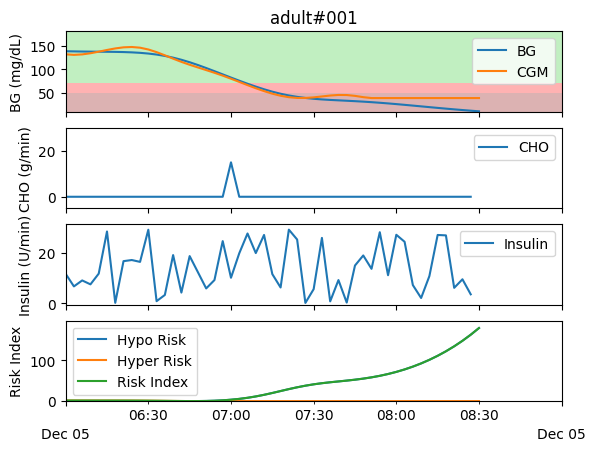

In [31]:
env = make_env(render=True)
obs, info = env.reset(seed=SEED)

print("Obs shape/type:", np.array(obs).shape, type(obs))
rewards = []
bg_values = []

for t in range(300):
    env.render()

    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)

    bg = info.get("bg", None)
    print(f"t={t}, BG={bg}, reward={reward}")

    rewards.append(float(reward))
    bg_values.append(bg)

    if terminated or truncated:
        break

print("\n--- Summary ---")
print("First 10 rewards:", rewards[:10])
print("Num steps:", len(rewards))

# ---------------- TIR / TBR / TAR ----------------
bg_arr = np.array([b for b in bg_values if b is not None], dtype=float)

TIR = np.mean((bg_arr >= 70) & (bg_arr <= 180)) * 100
TBR = np.mean(bg_arr < 70) * 100
TAR = np.mean(bg_arr > 180) * 100

print(f"\nTime In Range (70–180): {TIR:.2f}%")
print(f"Time Below Range (<70): {TBR:.2f}%")
print(f"Time Above Range (>180): {TAR:.2f}%")


In [ ]:
# env = make_env(render=True)
# obs, info = env.reset(seed=SEED)
# print("Obs shape/type:", np.array(obs).shape, type(obs))
# rewards = []
# bg_values = []

# for t in range(1000):          # large upper bound, env will terminate early
#     env.render()               # show live glucose plot

#     action = np.array([0], dtype=np.float32)   # <-- ZERO INSULIN
#     obs, reward, terminated, truncated, info = env.step(action)

#     # Extract true BG (depends on env version)
#     bg = info.get("bg", None)
#     if bg is None:
#         try:
#             bg = env.env.env.patient.state.BG
#         except:
#             bg = None

#     print(f"t={t}, BG={bg}, reward={reward:.4f}")

#     rewards.append(float(reward))
#     bg_values.append(bg)

#     if terminated or truncated:
#         break

# print("\nFirst 10 rewards:", rewards[:10])
# print("Episode length:", len(rewards))

# # ---- TIR / TBR / TAR ----
# bg_arr = np.array(bg_values, dtype=float)

# TIR = np.mean((bg_arr >= 70) & (bg_arr <= 180)) * 100
# TBR = np.mean(bg_arr < 70) * 100
# TAR = np.mean(bg_arr > 180) * 100

# print("\n===== BG Stats =====")
# print(f"TIR  (70–180 mg/dL): {TIR:.2f}%")
# print(f"TBR  (<70 mg/dL):    {TBR:.2f}%")
# print(f"TAR  (>180 mg/dL):   {TAR:.2f}%")

In [15]:
print(env.action_space)

Box(0.0, 30.0, (1,), float32)


In [16]:
env = make_env()
obs, info = env.reset(seed=SEED)
print(info)
print("keys:", list(info.keys()))


{'sample_time': np.float64(3.0), 'patient_name': 'adult#001', 'meal': 0, 'patient_state': array([  0.        ,   0.        ,   0.        , 265.09127058,
       156.88755688,   5.5043265 ,   0.        , 100.25      ,
       100.25      ,   3.20762505,  72.43417623, 141.15377933,
       265.25981447]), 'time': datetime.datetime(2025, 12, 5, 0, 0), 'bg': np.float64(138.50240939101715), 'lbgi': np.float64(0.0), 'hbgi': np.float64(1.5048632809013678), 'risk': np.float64(1.5048632809013678)}
keys: ['sample_time', 'patient_name', 'meal', 'patient_state', 'time', 'bg', 'lbgi', 'hbgi', 'risk']


In [37]:
env = make_env_stacked(seed=SEED, k=4)
env = make_env()
obs, info = env.reset()

print("Final obs:", obs)
print("Shape:", obs.shape)

for t in range(5):
    action = np.array([0.1], dtype=np.float32)
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"\nt={t}: {obs}")

Final obs: [0.3595987 0.25      0.       ]
Shape: (3,)

t=0: [0.35857573 0.25208333 0.        ]

t=1: [0.35538676 0.25416666 0.        ]

t=2: [0.3519283 0.25625   0.       ]

t=3: [0.34845996 0.25833333 0.        ]

t=4: [0.34520844 0.26041666 0.        ]


In [39]:
env = make_env()
obs, info = env.reset()

meal_obs_list = []   # <-- store only timesteps where meal_flag = 1
for t in range(480):   # 1 simulated day
    action = np.array([0.1], dtype=np.float32)   # arbitrary const action
    obs, reward, terminated, truncated, info = env.step(action)

    # meal value from env info
    meal = info.get("meal", 0.0)

    # meal_flag = 1 → store obs (ONLY then)
    if meal > 0:
        meal_obs_list.append((t, obs.copy(), float(meal)))

    if terminated or truncated:
        break

print("\n--- Timesteps with meals (meal_flag=1) ---")
for (t, o, m) in meal_obs_list:
    print(f"t={t}, meal={m}, obs={o}")


--- Timesteps with meals (meal_flag=1) ---
t=20, meal=15.0, obs=[0.36696708 0.29375    1.        ]
t=120, meal=23.333333333333332, obs=[0.23182563 0.50208336 1.        ]
t=200, meal=5.0, obs=[0.1206637 0.66875   1.       ]
t=240, meal=26.666666666666668, obs=[0.0975     0.75208336 1.        ]


In [ ]:
# env = make_env(render=True)
# observation, info = env.reset()
# for t in range(2000):
#     env.render()
#     action = env.action_space.sample()
#     observation, reward, terminated, truncated, info = env.step(action)
#     print(
#         f"Step {t}: observation {observation}, reward {reward}, terminated {terminated}, truncated {truncated}, info {info}"
#     )
#     if terminated or truncated:
#         print("Episode finished after {} timesteps".format(t + 1))
#         break

In [40]:

# # ---- Create Wrapped Env ----
# env = make_env()          # add seed
# env.reset(seed=SEED)      #
# env = Monitor(env, filename="ppo_train_monitor.csv")

def make_env_seeded(rank):
    def _init():
        return make_env(seed=SEED + rank)
    return _init

n_envs = 4
vec_env = DummyVecEnv([make_env_seeded(i) for i in range(n_envs)])
vec_env = VecMonitor(vec_env, filename="ppo_train_monitor_4envs.csv")


# policy_kwargs = dict(net_arch=[128, 128])      #hidden layer
# ---- Train PPO ----
model = PPO(
    "MlpPolicy",
    # env,
    vec_env,
    verbose=1,
    # policy_kwargs=policy_kwargs,
    learning_rate=3e-4,
    n_steps=1024,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    seed = SEED,
    ent_coef=0.1,
    tensorboard_log="./logs/"
)

model.learn(total_timesteps=100_000, tb_log_name="ppo_simglucose_scaled")


acts = []
env_test = make_env()
obs, info = env_test.reset(seed=0)
for _ in range(200):
    a, _ = model.predict(obs, deterministic=True)
    acts.append(float(np.array(a).flatten()[0]))
    obs, r, term, trunc, info = env_test.step(a)
    if term or trunc: break
print("action mean/std/min/max:", np.mean(acts), np.std(acts), np.min(acts), np.max(acts))


model.save("ppo_simglucose_scaled_adolescent2")

# ---- Evaluation (Stats Printing) ----
def evaluate(model, n_episodes=5):
    rewards = []
    for ep in range(n_episodes):
        # env = make_env()
        # obs, info = env.reset()

        env = make_env()
        obs, info = env.reset(seed=SEED + ep)
        done = False
        total_reward = 0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            done = terminated or truncated
        rewards.append(total_reward)

    rewards = np.array(rewards)
    print("\n=== PPO Evaluation Results ===")
    print(f"Episodes: {n_episodes}")
    print(f"Mean Reward: {rewards.mean():.2f}")
    print(f"Std Reward: {rewards.std():.2f}")
    print(f"Min Reward: {rewards.min():.2f}")
    print(f"Max Reward: {rewards.max():.2f}")
    return rewards

evaluate(model, n_episodes=5)

Using cpu device
Logging to ./logs/ppo_simglucose_scaled_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 108      |
|    ep_rew_mean     | -110     |
| time/              |          |
|    fps             | 86       |
|    iterations      | 1        |
|    time_elapsed    | 47       |
|    total_timesteps | 4096     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 106          |
|    ep_rew_mean          | -108         |
| time/                   |              |
|    fps                  | 85           |
|    iterations           | 2            |
|    time_elapsed         | 95           |
|    total_timesteps      | 8192         |
| train/                  |              |
|    approx_kl            | 0.0038315845 |
|    clip_fraction        | 0.0223       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.46        |

array([-70.91722971, -65.20213151, -68.1240793 , -79.56668901,
       -49.14436984])

In [ ]:
# la = pytz.timezone("America/Los_Angeles")
# timestamp = datetime.now(la).strftime("%H-%M")   # hour-minute with hyphen
# save_path = f"/content/drive/MyDrive/DiabeteseRL/ppo_simglucose_{timestamp}"

# model.save(save_path)
# print("Saved to:", save_path)

In [ ]:
# acts = []
# env_test = make_env()
# obs, info = env_test.reset(seed=0)
# for _ in range(200):
#     a, _ = model.predict(obs, deterministic=False)
#     acts.append(float(np.array(a).flatten()[0]))
#     obs, r, term, trunc, info = env_test.step(a)
#     if term or trunc: break
# print("action mean/std/min/max:", np.mean(acts), np.std(acts), np.min(acts), np.max(acts))

# # ---- Evaluation (Stats Printing) ----
# def evaluate(model, n_episodes=5):
#     rewards = []
#     for ep in range(n_episodes):
#         # env = make_env()
#         # obs, info = env.reset()

#         env = make_env()
#         obs, info = env.reset(seed=SEED + ep)
#         done = False
#         total_reward = 0
#         while not done:
#             action, _ = model.predict(obs, deterministic=False)
#             obs, reward, terminated, truncated, info = env.step(action)
#             total_reward += reward
#             done = terminated or truncated
#         rewards.append(total_reward)

#     rewards = np.array(rewards)
#     print("\n=== PPO Evaluation Results ===")
#     print(f"Episodes: {n_episodes}")
#     print(f"Mean Reward: {rewards.mean():.2f}")
#     print(f"Std Reward: {rewards.std():.2f}")
#     print(f"Min Reward: {rewards.min():.2f}")
#     print(f"Max Reward: {rewards.max():.2f}")
#     return rewards

# evaluate(model, n_episodes=5)

In [46]:
env_test = make_env()
obs, info = env_test.reset(seed=0)

for t in range(480):
    # PPO action
    action, _ = model.predict(obs, deterministic=True)

    # ----- GET TRUE BG -----
    try:
        bg = info.get("bg", None)
        if bg is None:
            bg = env_test.env.env.patient.state.BG
    except:
        bg = env_test.env.env.patient.state.BG
    # ------------------------
    # Print BG + action
    print(f"t={t}, BG={bg:.1f}, action={float(action):.4f}")

    # Step environment
    obs, reward, terminated, truncated, info = env_test.step(action)
    if terminated or truncated:
        break


t=0, BG=137.6, action=0.7801
t=1, BG=138.0, action=0.7767
t=2, BG=138.5, action=0.7704
t=3, BG=138.9, action=0.7685
t=4, BG=139.2, action=0.7705
t=5, BG=139.5, action=0.7759
t=6, BG=139.7, action=0.7842
t=7, BG=139.9, action=0.7947
t=8, BG=139.9, action=0.8070
t=9, BG=140.0, action=0.8204
t=10, BG=139.9, action=0.8343
t=11, BG=139.8, action=0.8481
t=12, BG=139.6, action=0.8610
t=13, BG=139.3, action=0.8723
t=14, BG=138.9, action=0.8814
t=15, BG=138.3, action=0.8878
t=16, BG=137.7, action=0.8916
t=17, BG=136.8, action=0.8927
t=18, BG=135.9, action=0.8912
t=19, BG=134.7, action=0.8871
t=20, BG=133.4, action=0.8802
t=21, BG=131.9, action=0.0000
t=22, BG=130.2, action=0.8570
t=23, BG=128.4, action=0.8401
t=24, BG=126.5, action=0.8197
t=25, BG=124.7, action=0.7969
t=26, BG=123.1, action=0.7738
t=27, BG=121.8, action=0.7527
t=28, BG=120.8, action=0.7357
t=29, BG=120.2, action=0.7246
t=30, BG=119.9, action=0.7194
t=31, BG=119.7, action=0.7185
t=32, BG=119.5, action=0.7196
t=33, BG=119.2, acti

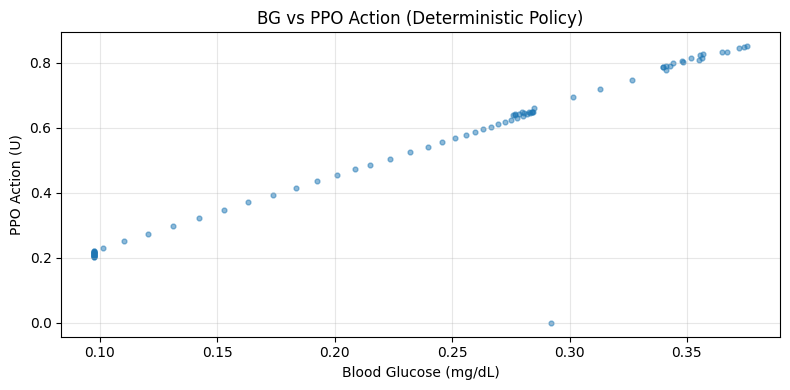

In [47]:
def evaluate_and_plot_actions(model, n_episodes=1):
    all_bg = []
    all_actions = []

    for ep in range(n_episodes):
        env = make_env()
        obs, info = env.reset(seed=SEED + ep)

        done = False
        while not done:
            # ---- PPO deterministic action ----
            action, _ = model.predict(obs, deterministic=True)

            # ---- Extract BG from observation ----
            # SimGlucose observation is a dict with key "BG"
            # If yours is different, adjust accordingly
            bg = obs["BG"] if isinstance(obs, dict) else obs[0]

            all_bg.append(float(bg))
            all_actions.append(float(action))

            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

    # ---- Plot: BG vs Action ----
    plt.figure(figsize=(8, 4))
    plt.scatter(all_bg, all_actions, alpha=0.5, s=12)
    plt.xlabel("Blood Glucose (mg/dL)")
    plt.ylabel("PPO Action (U)")
    plt.title("BG vs PPO Action (Deterministic Policy)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return np.array(all_bg), np.array(all_actions)

bg, acts = evaluate_and_plot_actions(model, n_episodes=1)


In [ ]:
# import os
# os.listdir("/content")

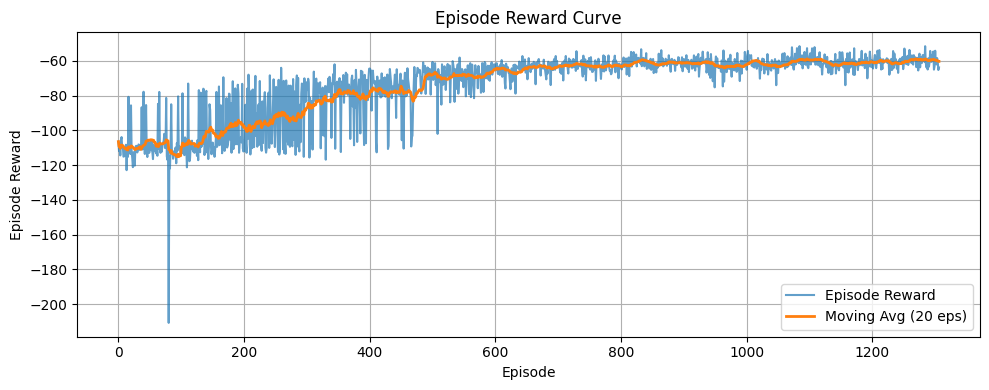

In [48]:
# data = pd.read_csv("ppo_train_monitor.csv", comment="#")
data = pd.read_csv("ppo_train_monitor_4envs.csv.monitor.csv", comment="#")

# Episode index
episodes = np.arange(len(data))

# Episode rewards
ep_rewards = data["r"]

plt.figure(figsize=(10,4))
plt.plot(episodes, ep_rewards, label="Episode Reward", alpha=0.7)

# Optional: moving average to smooth curve (recommended)
window = 20
if len(ep_rewards) > window:
    smoothed = ep_rewards.rolling(window, min_periods=1).mean()
    plt.plot(episodes, smoothed, label=f"Moving Avg ({window} eps)", linewidth=2)

plt.xlabel("Episode")
plt.ylabel("Episode Reward")
plt.title("Episode Reward Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# from datetime import datetime
# from zoneinfo import ZoneInfo
# la_time = datetime.now(ZoneInfo("America/Los_Angeles"))
# timestamp = la_time.strftime("%Y%m%d_%H%M")
# save_path = f"/content/drive/MyDrive/DiabeteseRL/reward_curve_{timestamp}.png"
# plt.savefig(save_path, dpi=300)
# print("Saved to:", save_path)


===== Simulation Stats =====
Mean BG                     : 87.935
Median BG                   : 106.586
Min BG                      : 8.913
Max BG                      : 138.418
TIR (70–180 mg/dL)          : 62.963
Time Below Range (%)        : 37.037
Time Above Range (%)        : 0.000
Total Insulin Delivered     : 42.986
Mean Insulin                : 0.531
Total Reward                : -61.689
Mean Reward                 : -0.762


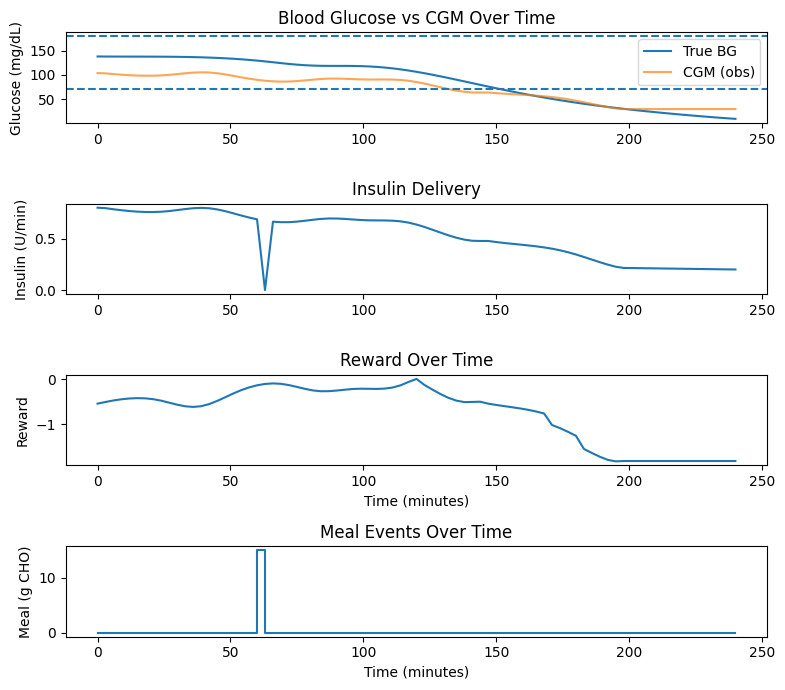

In [49]:
obs, info = env.reset()
bg_list = []
cgm_list = []          # <-- NEW
insulin_list = []
reward_list = []
meal_list = []

for t in range(1440):  # one simulated day (5 min steps)
    # record CGM (observation)
    try:
        cgm = float(obs[0])   # CGM is usually the first element of obs
    except:
        cgm = None
    cgm_list.append(cgm * 300 )

    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)

    # get true blood glucose safely
    try:
        bg = info.get('bg', None)
        if bg is None:
            bg = env.env.env.patient.state.BG
    except:
        bg = env.env.env.patient.state.BG

    bg_list.append(bg)
    insulin_list.append(float(np.array(action).flatten()[0]))
    reward_list.append(reward)

    meal = info.get("meal", 0.0)   # grams of carbs
    meal_list.append(float(meal))

    if terminated or truncated:
        break

# ---- Stats ----
bg_arr = np.array(bg_list)
ins_arr = np.array(insulin_list)
rew_arr = np.array(reward_list)

TIR = np.mean((bg_arr >= 70) & (bg_arr <= 180)) * 100
TBR = np.mean(bg_arr < 70) * 100
TAR = np.mean(bg_arr > 180) * 100

stats = {
    "Mean BG": np.mean(bg_arr),
    "Median BG": np.median(bg_arr),
    "Min BG": np.min(bg_arr),
    "Max BG": np.max(bg_arr),
    "TIR (70–180 mg/dL)": TIR,
    "Time Below Range (%)": TBR,
    "Time Above Range (%)": TAR,
    "Total Insulin Delivered": np.sum(ins_arr),
    "Mean Insulin": np.mean(ins_arr),
    "Total Reward": np.sum(rew_arr),
    "Mean Reward": np.mean(rew_arr),
}

print("\n===== Simulation Stats =====")
for k, v in stats.items():
    print(f"{k:28s}: {v:.3f}")

# ---- Plot ----
time = np.arange(len(bg_list)) * 3  # minutes of simulation     # 5 MIN OR 3 MIN??????

fig, axs = plt.subplots(4, 1, figsize=(8, 7), sharex=False)

# BG + CGM
axs[0].plot(time, bg_list, label="True BG")
axs[0].plot(time, cgm_list, label="CGM (obs)", alpha=0.7)
axs[0].axhline(70, linestyle='--')
axs[0].axhline(180, linestyle='--')
axs[0].set_ylabel("Glucose (mg/dL)")
axs[0].set_title("Blood Glucose vs CGM Over Time")
axs[0].legend()

# Insulin
axs[1].plot(time, insulin_list)
axs[1].set_ylabel("Insulin (U/min)")
axs[1].set_title("Insulin Delivery")
# axs[1].set_ylim(0, 1)

# Reward
axs[2].plot(time, reward_list)
axs[2].set_ylabel("Reward")
axs[2].set_xlabel("Time (minutes)")
axs[2].set_title("Reward Over Time")

# Meal (grams of carbs)
axs[3].step(time, meal_list, where='post')
axs[3].set_ylabel("Meal (g CHO)")
axs[3].set_xlabel("Time (minutes)")
axs[3].set_title("Meal Events Over Time")

plt.tight_layout()
plt.show()

Obs shape/type: (3,) <class 'numpy.ndarray'>
t=0, BG=137.8316184728535, reward=-0.8692060918106187, action=[0.8762032]
t=1, BG=138.69267744657074, reward=-0.8808370835134091, action=[0.87687594]
t=2, BG=139.23036127786727, reward=-0.8703212321060093, action=[0.87907714]
t=3, BG=139.5610685997966, reward=-0.847486439448405, action=[0.87650675]
t=4, BG=139.75689001576438, reward=-0.8172273047378391, action=[0.87064534]
t=5, BG=139.86072067920082, reward=-0.7838311048672002, action=[0.8627189]
t=6, BG=139.89597345470347, reward=-0.7511801352646187, action=[0.8537932]
t=7, BG=139.8729042442138, reward=-0.7228833177569423, action=[0.8448333]
t=8, BG=139.79280367905878, reward=-0.7020329316958231, action=[0.8367392]
t=9, BG=139.6508384255473, reward=-0.6896668691853148, action=[0.83030015]
t=10, BG=139.43803168046938, reward=-0.6840938475494257, action=[0.82586825]
t=11, BG=139.14268907486775, reward=-0.6834003511923729, action=[0.82316107]
t=12, BG=138.7514617418309, reward=-0.6857477679373

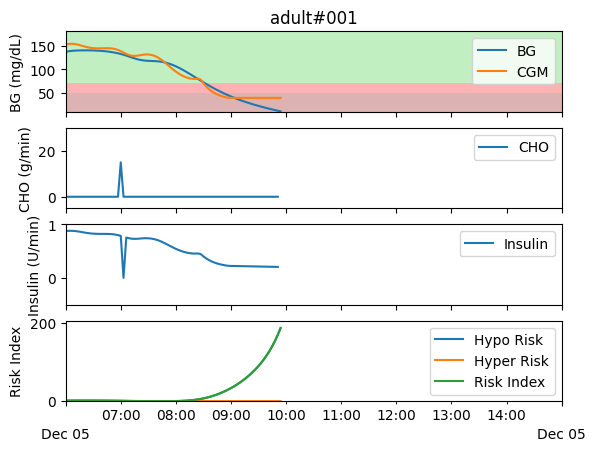

In [50]:
# IMPORTANT: same env config as training, but with render
env = make_env(seed=SEED, render=True)

obs, info = env.reset(seed=SEED)

print("Obs shape/type:", np.array(obs).shape, type(obs))
rewards = []
bg_values = []

for t in range(500):
    env.render()

    # PPO ACTION (not random)
    action, _ = model.predict(obs, deterministic=True)

    obs, reward, terminated, truncated, info = env.step(action)

    bg = info.get("bg", None)
    print(f"t={t}, BG={bg}, reward={reward}, action={action}")

    rewards.append(float(reward))
    bg_values.append(bg)

    if terminated or truncated:
        break

print("\n--- Summary ---")
print("First 10 rewards:", rewards[:10])
print("Num steps:", len(rewards))

bg_arr = np.array([b for b in bg_values if b is not None], dtype=float)
TIR = np.mean((bg_arr >= 70) & (bg_arr <= 180)) * 100
TBR = np.mean(bg_arr < 70) * 100
TAR = np.mean(bg_arr > 180) * 100

print(f"\nTime In Range (70–180): {TIR:.2f}%")
print(f"Time Below Range (<70): {TBR:.2f}%")
print(f"Time Above Range (>180): {TAR:.2f}%")


In [51]:
env_test = make_env()
obs, info = env_test.reset(seed=SEED)

steps = 0
for t in range(2000):        # large upper bound
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_test.step(action)
    steps += 1
    if terminated or truncated:
        break

print("Episode survived:", steps, "timesteps")

Episode survived: 81 timesteps


In [53]:
cgm_arr = np.array(cgm_list)
ins_arr = np.array(insulin_list)

print("corr(CGM, insulin):", np.corrcoef(cgm_arr, ins_arr)[0, 1])
print("CGM min/max:", cgm_arr.min(), cgm_arr.max())
print("Ins min/max:", ins_arr.min(), ins_arr.max())


corr(CGM, insulin): 0.9425202235082529
CGM min/max: 29.249998927116394 105.55620789527893
Ins min/max: 0.0 0.8055240511894226


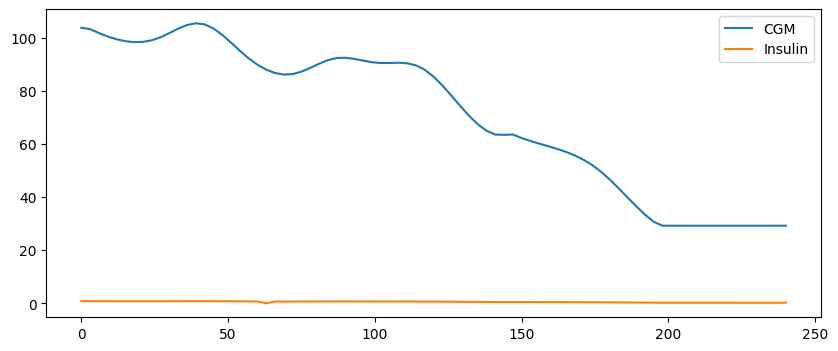

In [52]:
plt.figure(figsize=(10, 4))
plt.plot(time, cgm_list, label="CGM")
plt.plot(time, insulin_list, label="Insulin")
plt.legend()
plt.show()

In [54]:
print("act space:", env.action_space)
print("act low/high:", env.action_space.low, env.action_space.high)

# check obs is finite and not constant zeros
print("obs shape:", np.array(obs).shape, "finite:", np.isfinite(obs).all(), "min/max:", np.min(obs), np.max(obs))

act space: Box(0.0, 30.0, (1,), float32)
act low/high: [0.] [30.]
obs shape: (3,) finite: True min/max: 0.0 0.41875


In [55]:
env_test = make_env()
obs, info = env_test.reset(seed=0)

vals = []

for _ in range(200):
    vals.append(float(obs))
    obs, r, term, trunc, info = env_test.step([0.1])  # or any action
    if term or trunc:
        break

print("Episode CGM min/max:", min(vals), max(vals))

TypeError: only length-1 arrays can be converted to Python scalars

In [80]:
def run_episode(policy_type, env, model=None, const_action=0.3, seed=None, max_steps=10_000):
    """
    policy_type: 'ppo', 'random', or 'constant'
    """
    if seed is not None:
        obs, info = env.reset(seed=seed)
    else:
        obs, info = env.reset()

    steps = 0
    done = False

    while not done and steps < max_steps:
        if policy_type == "ppo":
            assert model is not None, "PPO policy needs a trained model."
            action, _ = model.predict(obs, deterministic=True)

        elif policy_type == "random":
            action = env.action_space.sample()

        elif policy_type == "constant":
            # env action space is Box([0], [1]), so 0.3 is valid
            action = np.array([const_action], dtype=np.float32)

        else:
            raise ValueError(f"Unknown policy_type: {policy_type}")

        obs, reward, terminated, truncated, info = env.step(action)
        steps += 1
        done = bool(terminated or truncated)

    return steps

In [81]:
def evaluate_survival(policy_type, model=None, n_episodes=20, const_action=0.3, base_seed=100):
    lengths = []

    for ep in range(n_episodes):
        env = make_env()  # fresh env each episode
        seed = base_seed + ep
        ep_len = run_episode(
            policy_type=policy_type,
            env=env,
            model=model,
            const_action=const_action,
            seed=seed
        )
        lengths.append(ep_len)

    lengths = np.array(lengths)
    print(f"\n=== Survival results: {policy_type.upper()} ===")
    print(f"Episodes: {n_episodes}")
    print(f"Mean steps: {lengths.mean():.1f}")
    print(f"Std steps:  {lengths.std():.1f}")
    print(f"Min steps:  {lengths.min():.0f}")
    print(f"Max steps:  {lengths.max():.0f}")
    return lengths


In [82]:
# PPO survival
ppo_lengths = evaluate_survival("ppo", model=model, n_episodes=20)
# Random survival
rand_lengths = evaluate_survival("random", model=None, n_episodes=20)
# Constant policy survival (e.g. always 0.3 insulin)
const_lengths = evaluate_survival("constant", model=None, n_episodes=20, const_action=0.3)


=== Survival results: PPO ===
Episodes: 20
Mean steps: 80.7
Std steps:  1.5
Min steps:  78
Max steps:  84

=== Survival results: RANDOM ===
Episodes: 20
Mean steps: 51.1
Std steps:  0.3
Min steps:  51
Max steps:  52

=== Survival results: CONSTANT ===
Episodes: 20
Mean steps: 116.0
Std steps:  0.0
Min steps:  116
Max steps:  116


In [83]:
def make_eval_env(patient_name):
    return gym.make(
        "simglucose/adult1-debug-v0",    # SAME env_id, same entry_point
        patient_name=patient_name,       # BUT override patient at eval time
        reward_fun=improved_reward,
        render_mode=None
    )



def eval_patient(model, patient_name):
    env = make_eval_env(patient_name)
    obs, info = env.reset(seed=0)

    bg_list = []
    steps = 0

    for t in range(2000):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        bg = info.get("bg", None)
        if bg is not None:
            bg_list.append(bg)
        steps += 1
        if terminated or truncated:
            break

    bg_arr = np.array(bg_list)
    TIR = np.mean((bg_arr >= 70) & (bg_arr <= 180)) * 100
    TBR = np.mean(bg_arr < 70) * 100
    TAR = np.mean(bg_arr > 180) * 100

    print(f"\n===== PATIENT {patient_name} =====")
    print("Episode steps survived:", steps)
    print(f"TIR: {TIR:.2f}%   TBR: {TBR:.2f}%   TAR: {TAR:.2f}%")


In [119]:
# eval_patient(model, "adult#001")
# eval_patient(model, "adult#002")
# eval_patient(model, "adult#003")
# eval_patient(model, "adult#004")
# eval_patient(model, "adult#005")
# eval_patient(model, "adult#006")
# eval_patient(model, "adult#007")
# eval_patient(model, "adult#008")
# eval_patient(model, "adult#009")
# eval_patient(model, "adult#010")

# eval_patient(model, "adolescent#001")
# eval_patient(model, "adolescent#002")
# eval_patient(model, "adolescent#003")
# eval_patient(model, "adolescent#004")
# eval_patient(model, "adolescent#005")
# eval_patient(model, "adolescent#006")
# eval_patient(model, "adolescent#007")
# eval_patient(model, "adolescent#008")
# eval_patient(model, "adolescent#009")
# eval_patient(model, "adolescent#010")

# eval_patient(model, "child#001")
# eval_patient(model, "child#002")
# eval_patient(model, "child#003")
# eval_patient(model, "child#004")
# eval_patient(model, "child#005")
# eval_patient(model, "child#006")
# eval_patient(model, "child#007")
# eval_patient(model, "child#008")
# eval_patient(model, "child#009")
# eval_patient(model, "child#010")

In [85]:
results = []

def eval_one_patient(model, patient_name):
    env = make_eval_env(patient_name)   # whatever you used already
    obs, info = env.reset(seed=SEED)
    bg_list = []
    steps = 0
    rewards = []

    while True:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)

        # BG from info or internal state
        bg = info.get("bg", None)
        if bg is None:
            try:
                bg = env.env.env.patient.state.BG
            except:
                bg = None

        if bg is not None:
            bg_list.append(bg)
        rewards.append(reward)
        steps += 1

        if terminated or truncated:
            break

    bg_arr = np.array(bg_list, dtype=float)

    TIR = np.mean((bg_arr >= 70) & (bg_arr <= 180)) * 100
    TBR = np.mean(bg_arr < 70) * 100
    TAR = np.mean(bg_arr > 180) * 100

    return steps, TIR, TBR, TAR

# ---- Run over patients & store results ----
adult_names      = [f"adult#{i:03d}" for i in range(1, 11)]
adolescent_names = [f"adolescent#{i:03d}" for i in range(1, 11)]
child_names      = [f"child#{i:03d}" for i in range(1, 11)]

for name in adult_names:
    steps, TIR, TBR, TAR = eval_one_patient(model, name)
    results.append({"group": "adult", "patient": name,
                    "steps": steps, "TIR": TIR, "TBR": TBR, "TAR": TAR})

for name in adolescent_names:
    steps, TIR, TBR, TAR = eval_one_patient(model, name)
    results.append({"group": "adolescent", "patient": name,
                    "steps": steps, "TIR": TIR, "TBR": TBR, "TAR": TAR})

for name in child_names:
    steps, TIR, TBR, TAR = eval_one_patient(model, name)
    results.append({"group": "child", "patient": name,
                    "steps": steps, "TIR": TIR, "TBR": TBR, "TAR": TAR})

df = pd.DataFrame(results)
print(df)

ValueError: Error: Unexpected observation shape (1,) for Box environment, please use (3,) or (n_env, 3) for the observation shape.

In [84]:

plt.figure(figsize=(8, 4))
for grp in ["adult", "adolescent", "child"]:
    sub = df[df["group"] == grp]
    plt.scatter([grp]*len(sub), sub["steps"])

plt.ylabel("Episode length (timesteps)")
plt.title("Episode Length per Patient by Cohort")
plt.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

<Figure size 800x400 with 0 Axes>

        group        TIR        TBR       TAR
0  adolescent  50.764232  40.559916  8.675852
1       adult  54.157150  42.537070  3.305780
2       child  41.131792  58.385450  0.482759


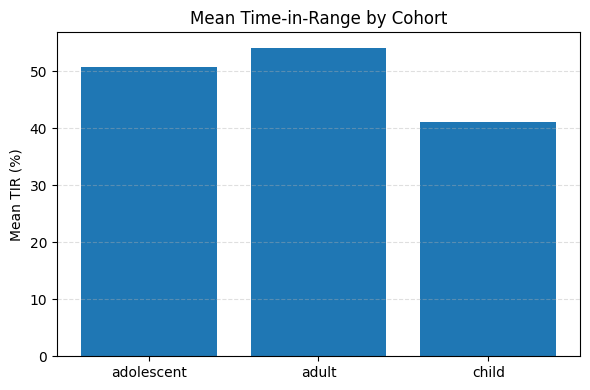

In [ ]:
group_stats = df.groupby("group")[["TIR", "TBR", "TAR"]].mean().reset_index()
print(group_stats)

plt.figure(figsize=(6, 4))
plt.bar(group_stats["group"], group_stats["TIR"])
plt.ylabel("Mean TIR (%)")
plt.title("Mean Time-in-Range by Cohort")
plt.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

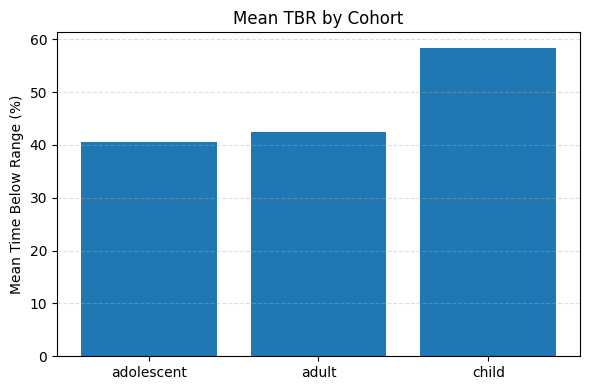

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(group_stats["group"], group_stats["TBR"])
plt.ylabel("Mean Time Below Range (%)")
plt.title("Mean TBR by Cohort")
plt.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


# Stacked Observations

In [64]:
# ---- 4-env factory using *stacked* env ----
def make_env_stacked_seeded(rank, k=4):
    def _init():
        return make_env_stacked(seed=SEED + rank, k=k)
    return _init

n_envs_stacked = 4
vec_env_stacked = DummyVecEnv([make_env_stacked_seeded(i) for i in range(n_envs_stacked)])
vec_env_stacked = VecMonitor(vec_env_stacked, filename="ppo_train_monitor_stacked_4envs.csv")

# ---- Train PPO with stacked observations ----
model_stacked = PPO(
    "MlpPolicy",
    vec_env_stacked,
    verbose=1,
    # policy_kwargs=policy_kwargs,   # optional, same as before if you want
    learning_rate=3e-4,
    n_steps=1024,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    seed=SEED,
    ent_coef=0.3,
    tensorboard_log="./logs/"
)

model_stacked.learn(total_timesteps=100_000, tb_log_name="ppo_simglucose_scaled_stacked")

# ---- Quick action stats on stacked env ----
acts = []
env_test_stacked = make_env_stacked()
obs, info = env_test_stacked.reset(seed=0)
for _ in range(200):
    a, _ = model_stacked.predict(obs, deterministic=True)
    acts.append(float(np.array(a).flatten()[0]))
    obs, r, term, trunc, info = env_test_stacked.step(a)
    if term or trunc:
        break
print(
    "STACKED action mean/std/min/max:",
    np.mean(acts),
    np.std(acts),
    np.min(acts),
    np.max(acts),
)

# ---- Save stacked model ----
model_stacked.save("ppo_simglucose_scaled_stacked_adult1")

# ---- Evaluation (Stats Printing) for stacked model ----
def evaluate_stacked(model, n_episodes=5):
    rewards = []
    for ep in range(n_episodes):
        env = make_env_stacked()
        obs, info = env.reset(seed=SEED + ep)
        done = False
        total_reward = 0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            done = terminated or truncated
        rewards.append(total_reward)

    rewards = np.array(rewards)
    print("\n=== PPO Evaluation Results (STACKED) ===")
    print(f"Episodes: {n_episodes}")
    print(f"Mean Reward: {rewards.mean():.2f}")
    print(f"Std Reward: {rewards.std():.2f}")
    print(f"Min Reward: {rewards.min():.2f}")
    print(f"Max Reward: {rewards.max():.2f}")
    return rewards

evaluate_stacked(model_stacked, n_episodes=5)

Using cpu device
Logging to ./logs/ppo_simglucose_scaled_stacked_3
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 114      |
|    ep_rew_mean     | -117     |
| time/              |          |
|    fps             | 71       |
|    iterations      | 1        |
|    time_elapsed    | 57       |
|    total_timesteps | 4096     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 113         |
|    ep_rew_mean          | -118        |
| time/                   |             |
|    fps                  | 77          |
|    iterations           | 2           |
|    time_elapsed         | 105         |
|    total_timesteps      | 8192        |
| train/                  |             |
|    approx_kl            | 0.029964844 |
|    clip_fraction        | 0.0696      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.51       |
|    

array([-1379.03205961, -1518.16227683, -1540.11585384, -1392.09321711,
       -1496.57671269])

In [114]:
# la = pytz.timezone("America/Los_Angeles")
# timestamp = datetime.now(la).strftime("%H-%M")   # hour-minute with hyphen
# save_path = f"/content/drive/MyDrive/DiabeteseRL/ppo_stacked_{timestamp}"

# model_stacked.save(save_path)
# print("Saved to:", save_path)

Saved to: /content/drive/MyDrive/DiabeteseRL/ppo_stacked_13-29


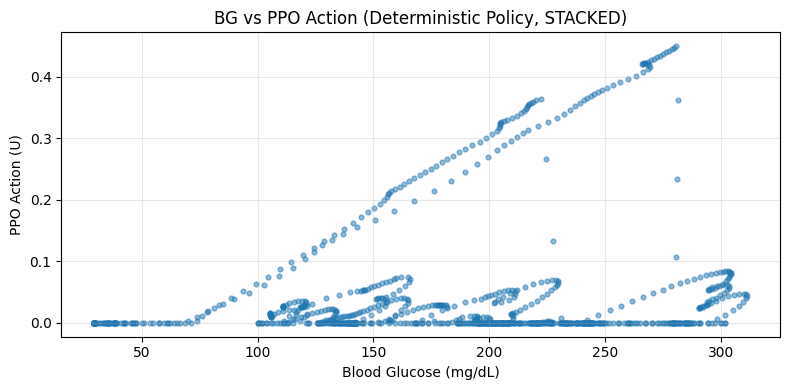

In [66]:
def evaluate_and_plot_actions_stacked(model, n_episodes=1, k=4):
    all_bg = []
    all_actions = []

    for ep in range(n_episodes):
        env = make_env_stacked(k=k)
        obs, info = env.reset(seed=SEED + ep)

        done = False
        while not done:
            # ---- PPO deterministic action ----
            action, _ = model.predict(obs, deterministic=True)

            # ---- Extract BG from STACKED obs ----
            # stack: [obs_t, obs_{t-1}, ..., obs_{t-k+1}]
            # most recent BG is in obs[0] (normalized)
            bg = float(obs[0] * 300.0)   # convert back to mg/dL

            all_bg.append(bg)
            all_actions.append(float(action))

            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

    # ---- Plot: BG vs Action ----
    plt.figure(figsize=(8, 4))
    plt.scatter(all_bg, all_actions, alpha=0.5, s=12)
    plt.xlabel("Blood Glucose (mg/dL)")
    plt.ylabel("PPO Action (U)")
    plt.title("BG vs PPO Action (Deterministic Policy, STACKED)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return np.array(all_bg), np.array(all_actions)

# Run it
bg_stacked, acts_stacked = evaluate_and_plot_actions_stacked(model_stacked, n_episodes=2)

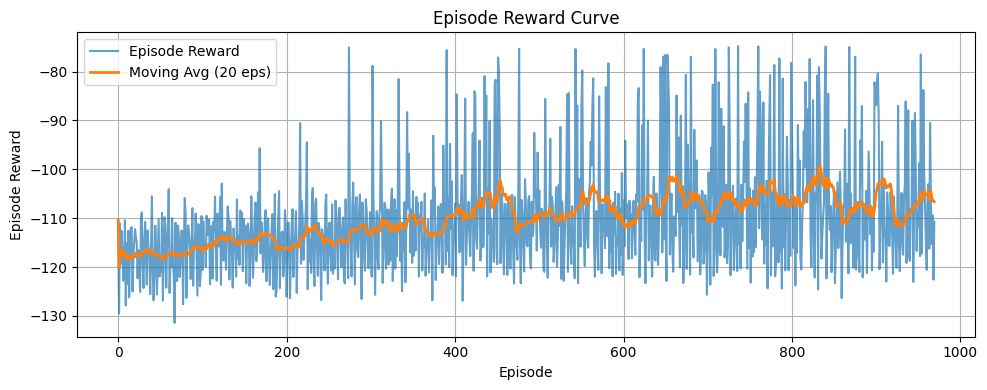

In [67]:
# data = pd.read_csv("ppo_train_monitor.csv", comment="#")
data = pd.read_csv("ppo_train_monitor_stacked_4envs.csv.monitor.csv", comment="#")

# Episode index
episodes = np.arange(len(data))

# Episode rewards
ep_rewards = data["r"]

plt.figure(figsize=(10,4))
plt.plot(episodes, ep_rewards, label="Episode Reward", alpha=0.7)

# Optional: moving average to smooth curve (recommended)
window = 20
if len(ep_rewards) > window:
    smoothed = ep_rewards.rolling(window, min_periods=1).mean()
    plt.plot(episodes, smoothed, label=f"Moving Avg ({window} eps)", linewidth=2)

plt.xlabel("Episode")
plt.ylabel("Episode Reward")
plt.title("Episode Reward Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# from datetime import datetime
# from zoneinfo import ZoneInfo
# la_time = datetime.now(ZoneInfo("America/Los_Angeles"))
# timestamp = la_time.strftime("%Y%m%d_%H%M")
# save_path = f"/content/drive/MyDrive/DiabeteseRL/reward_curve_stacked{timestamp}.png"
# plt.savefig(save_path, dpi=300)
# print("Saved to:", save_path)


===== Simulation Stats (STACKED) =====
Mean BG                     : 240.388
Median BG                   : 277.146
Min BG                      : 9.274
Max BG                      : 349.364
TIR (70–180 mg/dL)          : 13.983
Time Below Range (%)        : 8.051
Time Above Range (%)        : 77.966
Total Insulin Delivered     : 23.902
Mean Insulin                : 0.051
Total Reward                : -1440.610
Mean Reward                 : -3.052


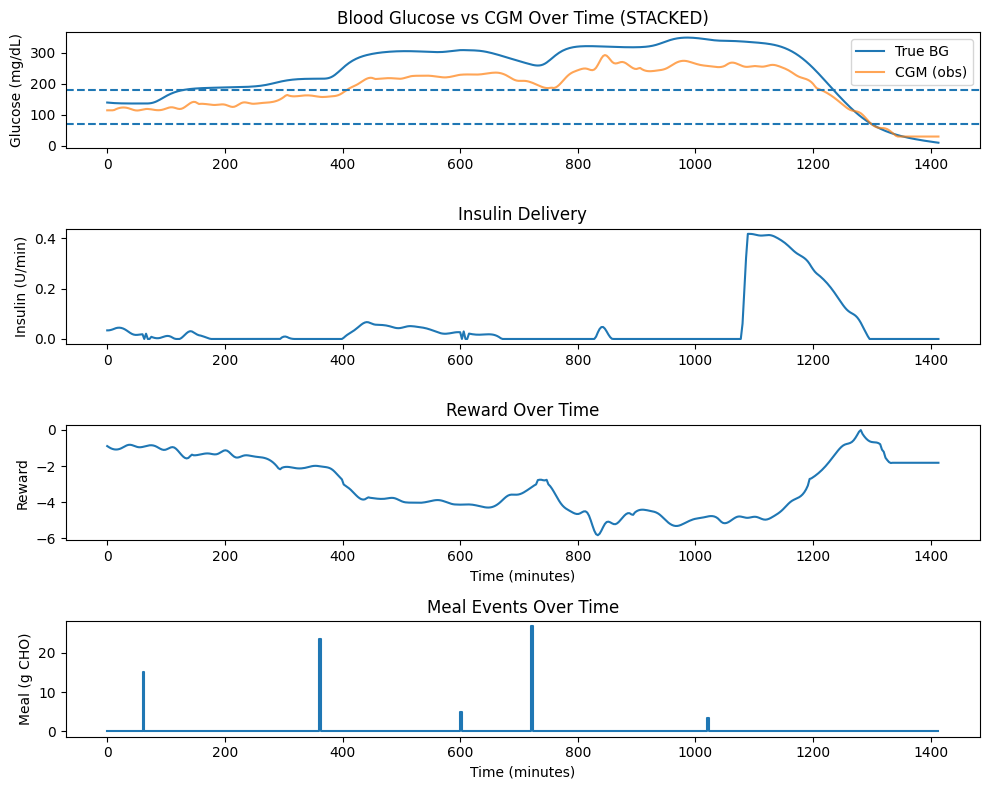

In [73]:
# ---- Use STACKED env + STACKED model ----
env = make_env_stacked(k=4)
obs, info = env.reset(seed=SEED)

bg_list = []
cgm_list = []
insulin_list = []
reward_list = []
meal_list = []

for t in range(1440):  # one simulated day
    # record CGM from STACKED obs
    # obs[0] = normalized CGM_t in [0,1], so scale back:
    try:
        cgm = float(obs[0] * 300.0)
    except Exception:
        cgm = None
    cgm_list.append(cgm)

    # PPO deterministic action
    action, _ = model_stacked.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)

    # get true blood glucose safely (from info)
    bg = info.get("bg", np.nan)
    bg_list.append(bg)

    insulin_list.append(float(np.array(action).flatten()[0]))
    reward_list.append(reward)

    meal = info.get("meal", 0.0)   # grams of carbs
    meal_list.append(float(meal))


    if terminated or truncated:
        break

# ---- Stats ----
bg_arr = np.array(bg_list, dtype=float)
ins_arr = np.array(insulin_list, dtype=float)
rew_arr = np.array(reward_list, dtype=float)

TIR = np.mean((bg_arr >= 70) & (bg_arr <= 180)) * 100
TBR = np.mean(bg_arr < 70) * 100
TAR = np.mean(bg_arr > 180) * 100

stats = {
    "Mean BG": np.mean(bg_arr),
    "Median BG": np.median(bg_arr),
    "Min BG": np.min(bg_arr),
    "Max BG": np.max(bg_arr),
    "TIR (70–180 mg/dL)": TIR,
    "Time Below Range (%)": TBR,
    "Time Above Range (%)": TAR,
    "Total Insulin Delivered": np.sum(ins_arr),
    "Mean Insulin": np.mean(ins_arr),
    "Total Reward": np.sum(rew_arr),
    "Mean Reward": np.mean(rew_arr),
}

print("\n===== Simulation Stats (STACKED) =====")
for k_name, v in stats.items():
    print(f"{k_name:28s}: {v:.3f}")

# ---- Plot ----
# SimGlucose default step is 5 minutes
time = np.arange(len(bg_list)) * 3 # minutes of simulation

fig, axs = plt.subplots(4, 1, figsize=(10, 8), sharex=False)

# BG + CGM
axs[0].plot(time, bg_list, label="True BG")
axs[0].plot(time, cgm_list, label="CGM (obs)", alpha=0.7)
axs[0].axhline(70, linestyle='--')
axs[0].axhline(180, linestyle='--')
axs[0].set_ylabel("Glucose (mg/dL)")
axs[0].set_title("Blood Glucose vs CGM Over Time (STACKED)")
axs[0].legend()

# Insulin
axs[1].plot(time, insulin_list)
axs[1].set_ylabel("Insulin (U/min)")
axs[1].set_title("Insulin Delivery")

# Reward
axs[2].plot(time, reward_list)
axs[2].set_ylabel("Reward")
axs[2].set_xlabel("Time (minutes)")
axs[2].set_title("Reward Over Time")

# Meal (grams of carbs)
axs[3].step(time, meal_list, where='post')
axs[3].set_ylabel("Meal (g CHO)")
axs[3].set_xlabel("Time (minutes)")
axs[3].set_title("Meal Events Over Time")

plt.tight_layout()
plt.show()

Obs shape/type: (12,) <class 'numpy.ndarray'>
t=0, BG=138.12774364518478, reward=-0.5667116862777756, action=[0.01404359]
t=1, BG=138.67488713777092, reward=-0.5771750164361336, action=[0.01358941]
t=2, BG=139.02499795246237, reward=-0.602042013319039, action=[0.01278764]
t=3, BG=139.24808771451458, reward=-0.6423883513249804, action=[0.01209748]
t=4, BG=139.38911911454414, reward=-0.6915718569205951, action=[0.01190497]
t=5, BG=139.47702991138982, reward=-0.7426158138432697, action=[0.01268973]
t=6, BG=139.53049954608338, reward=-0.7883293587056418, action=[0.01447971]
t=7, BG=139.56163528679963, reward=-0.8213844408476607, action=[0.01675871]
t=8, BG=139.57832858038003, reward=-0.8353329963232972, action=[0.01898572]
t=9, BG=139.5857608048994, reward=-0.8293169346034731, action=[0.02062123]
t=10, BG=139.58736483400602, reward=-0.8101854976647271, action=[0.02123051]
t=11, BG=139.58543878389304, reward=-0.7852482663041599, action=[0.02062777]
t=12, BG=139.5815380951142, reward=-0.7614

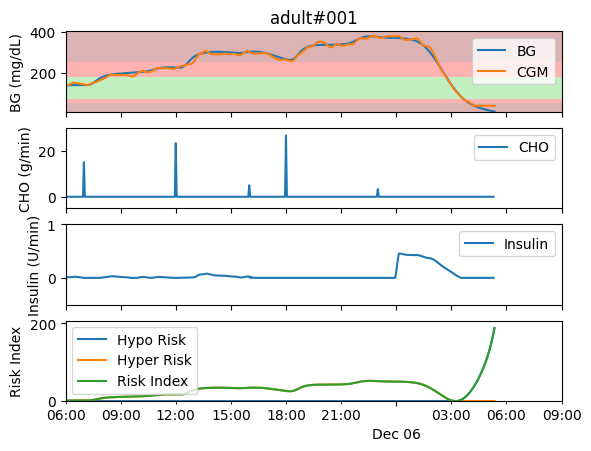

In [74]:
# IMPORTANT: same env configuration as training, but with render
env = make_env_stacked(k=4, seed=SEED, render=True)

obs, info = env.reset(seed=SEED)

print("Obs shape/type:", np.array(obs).shape, type(obs))
rewards = []
bg_values = []
insulin_list = []     # <-- ADD THIS

for t in range(500):
    env.render()

    # PPO ACTION (stacked model)
    action, _ = model_stacked.predict(obs, deterministic=True)

    obs, reward, terminated, truncated, info = env.step(action)

    # BG from info (true BG from simulator)
    bg = info.get("bg", None)

    print(f"t={t}, BG={bg}, reward={reward}, action={action}")

    rewards.append(float(reward))
    bg_values.append(bg)
    insulin_list.append(float(action))   # <-- STORE INSULIN HERE

    if terminated or truncated:
        break

print("\n--- Summary ---")
print("First 10 rewards:", rewards[:10])
print("Num steps:", len(rewards))

# --- Time in range stats ---
bg_arr = np.array([b for b in bg_values if b is not None], dtype=float)
TIR = np.mean((bg_arr >= 70) & (bg_arr <= 180)) * 100
TBR = np.mean(bg_arr < 70) * 100
TAR = np.mean(bg_arr > 180) * 100

print(f"\nTime In Range (70–180): {TIR:.2f}%")
print(f"Time Below Range (<70): {TBR:.2f}%")
print(f"Time Above Range (>180): {TAR:.2f}%")



In [117]:
# plt.plot(insulin_list)
# # plt.ylim(0.08, 0.13)
# plt.title("Insulin Delivery Over Time")
# plt.show()


In [86]:
cgm_arr = np.array(cgm_list)
ins_arr = np.array(insulin_list)

print("corr(CGM, insulin):", np.corrcoef(cgm_arr, ins_arr)[0, 1])
print("CGM min/max:", cgm_arr.min(), cgm_arr.max())
print("Ins min/max:", ins_arr.min(), ins_arr.max())

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 472 and the array at index 1 has size 468

In [88]:
env_test = make_env_stacked(k=4)      # <-- use stacked env
obs, info = env_test.reset(seed=SEED)

steps = 0
for t in range(2000):                 # large upper bound
    action, _ = model_stacked.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_test.step(action)

    steps += 1
    if terminated or truncated:
        break

print("Survived steps:", steps)

Survived steps: 472


In [89]:
def evaluate_survival(policy_type, model=None, n_episodes=20, const_action=0.3, base_seed=100):
    lengths = []

    for ep in range(n_episodes):
        env = make_env()  # fresh env each episode
        seed = base_seed + ep
        ep_len = run_episode(
            policy_type=policy_type,
            env=env,
            model=model,
            const_action=const_action,
            seed=seed
        )
        lengths.append(ep_len)

    lengths = np.array(lengths)
    print(f"\n=== Survival results: {policy_type.upper()} ===")
    print(f"Episodes: {n_episodes}")
    print(f"Mean steps: {lengths.mean():.1f}")
    print(f"Std steps:  {lengths.std():.1f}")
    print(f"Min steps:  {lengths.min():.0f}")
    print(f"Max steps:  {lengths.max():.0f}")
    return lengths

def evaluate_survival_stacked(policy_type, model=None, n_episodes=20, const_action=0.3, base_seed=100, k=4):
    lengths = []

    for ep in range(n_episodes):
        env = make_env_stacked(k=k)  # ✅ stacked env
        seed = base_seed + ep
        ep_len = run_episode(
            policy_type=policy_type,
            env=env,
            model=model,
            const_action=const_action,
            seed=seed
        )
        lengths.append(ep_len)

    lengths = np.array(lengths)
    print(f"\n=== Survival results: {policy_type.upper()} ===")
    print(f"Episodes: {n_episodes}")
    print(f"Mean steps: {lengths.mean():.1f}")
    print(f"Std steps:  {lengths.std():.1f}")
    print(f"Min steps:  {lengths.min():.0f}")
    print(f"Max steps:  {lengths.max():.0f}")
    return lengths


# PPO survival
ppo_lengths = evaluate_survival("ppo", model=model, n_episodes=20)
stacked_ppo_lengths = evaluate_survival_stacked("ppo", model=model_stacked, n_episodes=20)      #STACKED
# Random survival
rand_lengths = evaluate_survival("random", model=None, n_episodes=20)
# Constant policy survival (e.g. always 0.3 insulin)
const_lengths = evaluate_survival("constant", model=None, n_episodes=20, const_action=0.2)
const_lengths = evaluate_survival("constant", model=None, n_episodes=20, const_action=0.1)
const_lengths = evaluate_survival("constant", model=None, n_episodes=20, const_action=0)


=== Survival results: PPO ===
Episodes: 20
Mean steps: 80.3
Std steps:  1.7
Min steps:  77
Max steps:  85

=== Survival results: PPO ===
Episodes: 20
Mean steps: 471.1
Std steps:  4.2
Min steps:  464
Max steps:  480

=== Survival results: RANDOM ===
Episodes: 20
Mean steps: 51.0
Std steps:  0.0
Min steps:  51
Max steps:  51

=== Survival results: CONSTANT ===
Episodes: 20
Mean steps: 174.0
Std steps:  0.0
Min steps:  174
Max steps:  174

=== Survival results: CONSTANT ===
Episodes: 20
Mean steps: 242.0
Std steps:  0.0
Min steps:  242
Max steps:  242

=== Survival results: CONSTANT ===
Episodes: 20
Mean steps: 480.0
Std steps:  0.0
Min steps:  480
Max steps:  480


##**RECURRENT** **PPO**:

In [101]:
# --------------------------------------------------------
# Vectorized env (same pattern as before)
# --------------------------------------------------------
def make_env_seeded(rank):
    def _init():
        # you can swap make_env -> make_env_stacked(...) later if you want
        return make_env(seed=SEED + rank)
    return _init

n_envs = 4
vec_env_recurrent = DummyVecEnv([make_env_seeded(i) for i in range(n_envs)])
vec_env_recurrent = VecMonitor(vec_env_recurrent,
                               filename="recurrent_ppo_train_monitor_4envs.csv")

# --------------------------------------------------------
# Train Recurrent PPO (LSTM policy)
# --------------------------------------------------------
recurrent_model = RecurrentPPO(
    "MlpLstmPolicy",
    vec_env_recurrent,
    verbose=1,
    learning_rate=3e-4,
    n_steps=1024,       # maybe reduce this ?
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    seed=SEED,
    ent_coef=0.1,
    tensorboard_log="./logs/"
)

recurrent_model.learn(
    total_timesteps=30_000,
    tb_log_name="recurrent_ppo_simglucose_scaled"
)

# --------------------------------------------------------
# Quick action stats on a single eval env
# --------------------------------------------------------
env_test = make_env()   # or make_env_stacked(...) if this is the stacked version
obs, info = env_test.reset(seed=0)

acts = []
lstm_state = None
episode_start = True

for _ in range(200):
    action, lstm_state = recurrent_model.predict(
        obs,
        state=lstm_state,
        episode_start=episode_start,
        deterministic=True,
    )
    acts.append(float(np.array(action).flatten()[0]))

    obs, r, term, trunc, info = env_test.step(action)
    done = bool(term or trunc)
    episode_start = done
    if done:
        break

print(
    "Recurrent PPO action mean/std/min/max:",
    np.mean(acts),
    np.std(acts),
    np.min(acts),
    np.max(acts),
)

# --------------------------------------------------------
# Save model
# --------------------------------------------------------
recurrent_model.save("recurrent_ppo_simglucose_scaled_adult1")

# --------------------------------------------------------
# Evaluation helper (episodes of 1 env, like before)
# --------------------------------------------------------
def evaluate_recurrent(model, n_episodes=5):
    rewards = []

    for ep in range(n_episodes):
        env = make_env()   # or make_env_stacked(...) if this is the stacked version
        obs, info = env.reset(seed=SEED + ep)

        lstm_state = None
        episode_start = True
        done = False
        total_reward = 0.0

        while not done:
            action, lstm_state = model.predict(
                obs,
                state=lstm_state,
                episode_start=episode_start,
                deterministic=True,
            )
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            done = bool(terminated or truncated)
            episode_start = done

        rewards.append(total_reward)

    rewards = np.array(rewards)
    print("\n=== Recurrent PPO Evaluation Results ===")
    print(f"Episodes: {n_episodes}")
    print(f"Mean Reward: {rewards.mean():.2f}")
    print(f"Std Reward:  {rewards.std():.2f}")
    print(f"Min Reward:  {rewards.min():.2f}")
    print(f"Max Reward:  {rewards.max():.2f}")
    return rewards

evaluate_recurrent(recurrent_model, n_episodes=5)


Using cpu device
Logging to ./logs/recurrent_ppo_simglucose_scaled_3
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 107      |
|    ep_rew_mean     | -111     |
| time/              |          |
|    fps             | 78       |
|    iterations      | 1        |
|    time_elapsed    | 52       |
|    total_timesteps | 4096     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 107          |
|    ep_rew_mean          | -111         |
| time/                   |              |
|    fps                  | 42           |
|    iterations           | 2            |
|    time_elapsed         | 193          |
|    total_timesteps      | 8192         |
| train/                  |              |
|    approx_kl            | 0.0014496422 |
|    clip_fraction        | 0.00947      |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.4

array([-359.54121961, -347.22360821, -320.47757578, -315.42336072,
       -324.47741569])

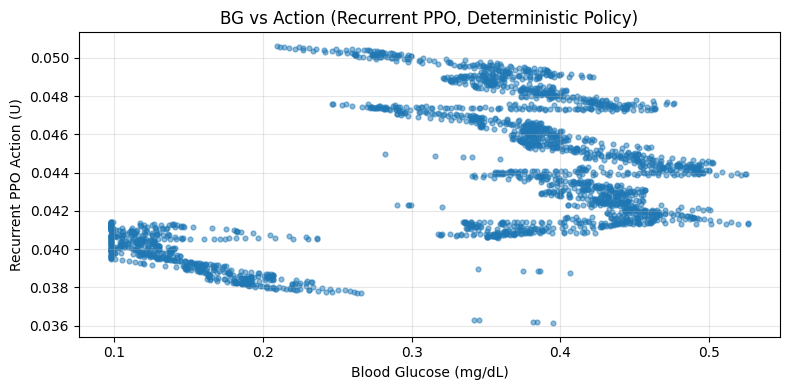

In [102]:
def evaluate_and_plot_actions_recurrent(model, n_episodes=1):
    all_bg = []
    all_actions = []

    for ep in range(n_episodes):
        env = make_env()  # or make_env_stacked() depending on what you're testing
        obs, info = env.reset(seed=SEED + ep)

        # --- IMPORTANT: recurrent policy needs hidden state + mask ---
        state = None
        done = False
        lstm_mask = np.array([1.0])  # 1 = new sequence continues

        while not done:
            # ---- Recurrent PPO deterministic action ----
            action, state = model.predict(
                obs,
                state=state,
                episode_start=lstm_mask,
                deterministic=True
            )

            # ---- Extract BG from observation ----
            bg = obs["BG"] if isinstance(obs, dict) else obs[0]

            all_bg.append(float(bg))
            all_actions.append(float(action))

            # --- Step environment ---
            obs, reward, terminated, truncated, info = env.step(action)

            done = terminated or truncated

            # --- Update LSTM mask ---
            lstm_mask = np.array([0.0]) if done else np.array([1.0])

    # ---- Plot: BG vs Action ----
    plt.figure(figsize=(8, 4))
    plt.scatter(all_bg, all_actions, alpha=0.5, s=12)
    plt.xlabel("Blood Glucose (mg/dL)")
    plt.ylabel("Recurrent PPO Action (U)")
    plt.title("BG vs Action (Recurrent PPO, Deterministic Policy)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return np.array(all_bg), np.array(all_actions)

bg, acts = evaluate_and_plot_actions_recurrent(recurrent_model , n_episodes=5)

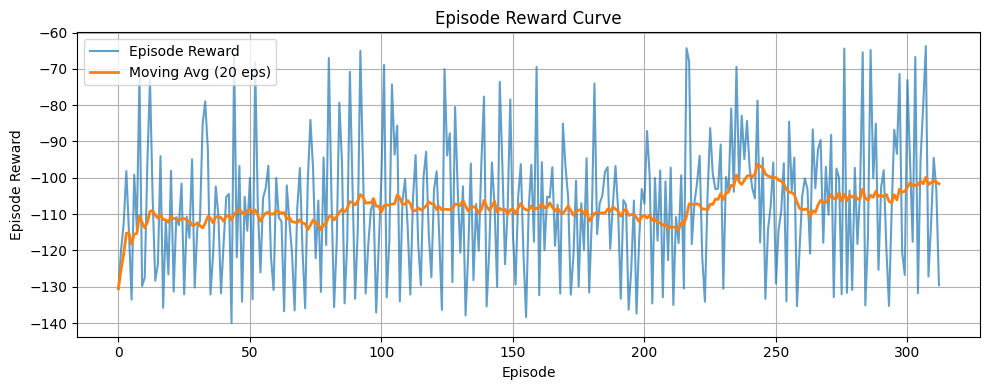

In [103]:
# data = pd.read_csv("ppo_train_monitor.csv", comment="#")
data = pd.read_csv("recurrent_ppo_train_monitor_4envs.csv.monitor.csv", comment="#")

# Episode index
episodes = np.arange(len(data))

# Episode rewards
ep_rewards = data["r"]

plt.figure(figsize=(10,4))
plt.plot(episodes, ep_rewards, label="Episode Reward", alpha=0.7)

# Optional: moving average to smooth curve (recommended)
window = 20
if len(ep_rewards) > window:
    smoothed = ep_rewards.rolling(window, min_periods=1).mean()
    plt.plot(episodes, smoothed, label=f"Moving Avg ({window} eps)", linewidth=2)

plt.xlabel("Episode")
plt.ylabel("Episode Reward")
plt.title("Episode Reward Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



# la_time = datetime.now(ZoneInfo("America/Los_Angeles"))
# timestamp = la_time.strftime("%Y%m%d_%H%M")
# save_path = f"/content/drive/MyDrive/DiabeteseRL/reward_curve_recurrent_{timestamp}.png"
# plt.savefig(save_path, dpi=300)
# print("Saved to:", save_path)


===== Simulation Stats (Recurrent PPO) =====
Mean BG                     : 94.679
Median BG                   : 87.561
Min BG                      : 9.661
Max BG                      : 177.120
TIR (70–180 mg/dL)          : 67.218
Time Below Range (%)        : 32.782
Time Above Range (%)        : 0.000
Total Insulin Delivered     : 29.553
Mean Insulin                : 0.081
Total Reward                : -348.827
Mean Reward                 : -0.961


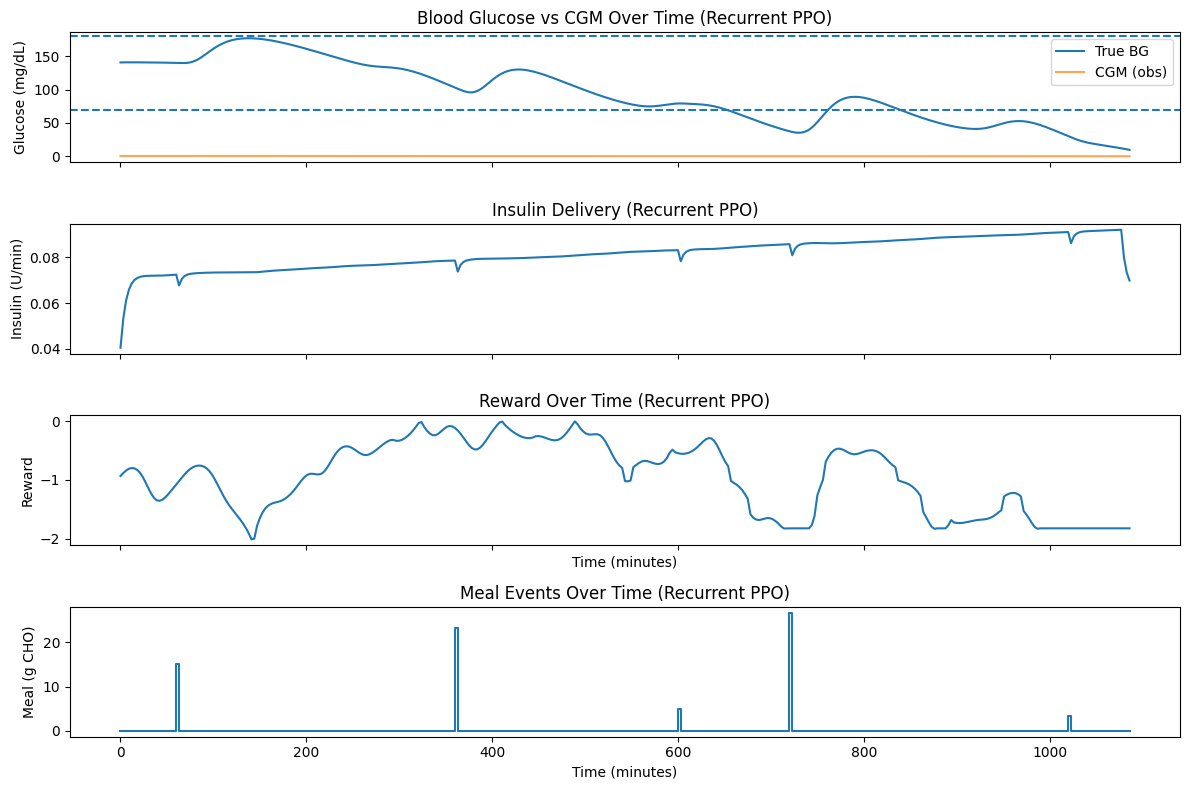

In [105]:
# ---- Reset a fresh eval environment ----
env = make_env()
obs, info = env.reset(seed=123)

# ---- Recurrent PPO states ----
lstm_state = None
episode_start = np.array([True])

bg_list = []
cgm_list = []
insulin_list = []
reward_list = []
meal_list = []

for t in range(1440):  # one simulated day (5 min steps)

    # record CGM observation
    try:
        cgm = float(obs[0])
    except:
        cgm = None
    cgm_list.append(cgm)

    # recurrent PPO prediction
    action, lstm_state = recurrent_model.predict(
        obs,
        state=lstm_state,
        episode_start=episode_start,
        deterministic=True,
    )

    obs, reward, terminated, truncated, info = env.step(action)

    # true BG
    try:
        bg = info.get("bg", None)
        if bg is None:
            bg = env.env.env.patient.state.BG
    except:
        bg = env.env.env.patient.state.BG
    bg_list.append(bg)

    # insulin
    insulin_list.append(float(np.array(action).flatten()[0]))

    # reward
    reward_list.append(reward)


    meal = info.get("meal", 0.0)   # grams of carbs
    meal_list.append(float(meal))

    done = terminated or truncated
    episode_start = np.array([done])

    if done:
        break

# ---- Stats ----
bg_arr = np.array(bg_list)
ins_arr = np.array(insulin_list)
rew_arr = np.array(reward_list)

TIR = np.mean((bg_arr >= 70) & (bg_arr <= 180)) * 100
TBR = np.mean(bg_arr < 70) * 100
TAR = np.mean(bg_arr > 180) * 100

stats = {
    "Mean BG": np.mean(bg_arr),
    "Median BG": np.median(bg_arr),
    "Min BG": np.min(bg_arr),
    "Max BG": np.max(bg_arr),
    "TIR (70–180 mg/dL)": TIR,
    "Time Below Range (%)": TBR,
    "Time Above Range (%)": TAR,
    "Total Insulin Delivered": np.sum(ins_arr),
    "Mean Insulin": np.mean(ins_arr),
    "Total Reward": np.sum(rew_arr),
    "Mean Reward": np.mean(rew_arr),
}

print("\n===== Simulation Stats (Recurrent PPO) =====")
for k, v in stats.items():
    print(f"{k:28s}: {v:.3f}")

# ---- Plot ----
time = np.arange(len(bg_list)) * 3  # minutes

fig, axs = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

# BG + CGM
axs[0].plot(time, bg_list, label="True BG")
axs[0].plot(time, cgm_list, label="CGM (obs)", alpha=0.7)
axs[0].axhline(70, linestyle='--')
axs[0].axhline(180, linestyle='--')
axs[0].set_ylabel("Glucose (mg/dL)")
axs[0].set_title("Blood Glucose vs CGM Over Time (Recurrent PPO)")
axs[0].legend()

# Insulin delivery
axs[1].plot(time, insulin_list)
axs[1].set_ylabel("Insulin (U/min)")
axs[1].set_title("Insulin Delivery (Recurrent PPO)")

# Reward over time
axs[2].plot(time, reward_list)
axs[2].set_ylabel("Reward")
axs[2].set_xlabel("Time (minutes)")
axs[2].set_title("Reward Over Time (Recurrent PPO)")


# Meal (grams of carbs)
axs[3].step(time, meal_list, where='post')
axs[3].set_ylabel("Meal (g CHO)")
axs[3].set_xlabel("Time (minutes)")
axs[3].set_title("Meal Events Over Time (Recurrent PPO)")

plt.tight_layout()
plt.show()


Obs shape/type: (3,) <class 'numpy.ndarray'>
t=0, BG=141.89594766213511, reward=-0.9276255417528159, action=[0.04048068]
t=1, BG=141.2566568396244, reward=-0.8743870817449887, action=[0.04051278]
t=2, BG=140.72550553536567, reward=-0.8060908924330081, action=[0.04055858]
t=3, BG=140.28872487105983, reward=-0.7268312478651073, action=[0.04061243]
t=4, BG=139.9322633974001, reward=-0.6434059263579814, action=[0.04067145]
t=5, BG=139.6429407525348, reward=-0.5626291696882976, action=[0.04073276]
t=6, BG=139.40896445502887, reward=-0.49134283025182085, action=[0.04079351]
t=7, BG=139.22008683172407, reward=-0.43641992959210496, action=[0.04085083]
t=8, BG=139.06756881123403, reward=-0.4039248876663561, action=[0.04090186]
t=9, BG=138.9440491853956, reward=-0.3950546545101388, action=[0.04094398]
t=10, BG=138.84337617068155, reward=-0.4043169844762597, action=[0.04097636]
t=11, BG=138.76043276196768, reward=-0.425821180818047, action=[0.04100078]
t=12, BG=138.69097221989495, reward=-0.45397

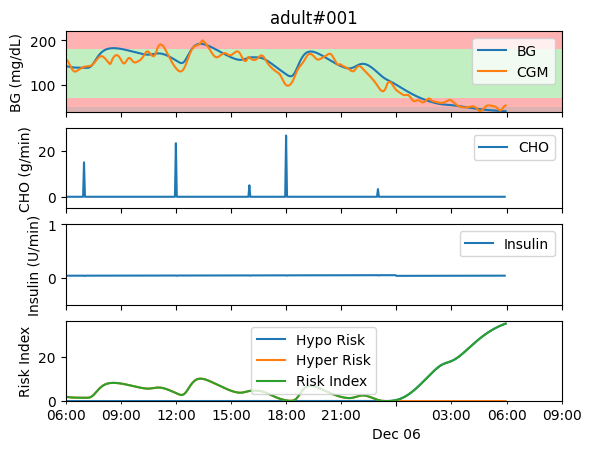

In [106]:
env = make_env(seed=SEED, render=True)

obs, info = env.reset(seed=SEED)

print("Obs shape/type:", np.array(obs).shape, type(obs))
rewards = []
bg_values = []
actions = []   # <-- store actions here

for t in range(500):
    env.render()

    # PPO ACTION (not random)
    action, _ = recurrent_model.predict(obs, deterministic=True)

    obs, reward, terminated, truncated, info = env.step(action)

    bg = info.get("bg", None)
    print(f"t={t}, BG={bg}, reward={reward}, action={action}")

    rewards.append(float(reward))
    bg_values.append(bg)
    actions.append(action)   # <-- log action each step

    if terminated or truncated:
        break

print("\n--- Summary ---")
print("First 10 rewards:", rewards[:10])
print("Num steps:", len(rewards))

bg_arr = np.array([b for b in bg_values if b is not None], dtype=float)
TIR = np.mean((bg_arr >= 70) & (bg_arr <= 180)) * 100
TBR = np.mean(bg_arr < 70) * 100
TAR = np.mean(bg_arr > 180) * 100

print(f"\nTime In Range (70–180): {TIR:.2f}%")
print(f"Time Below Range (<70): {TBR:.2f}%")
print(f"Time Above Range (>180): {TAR:.2f}%")


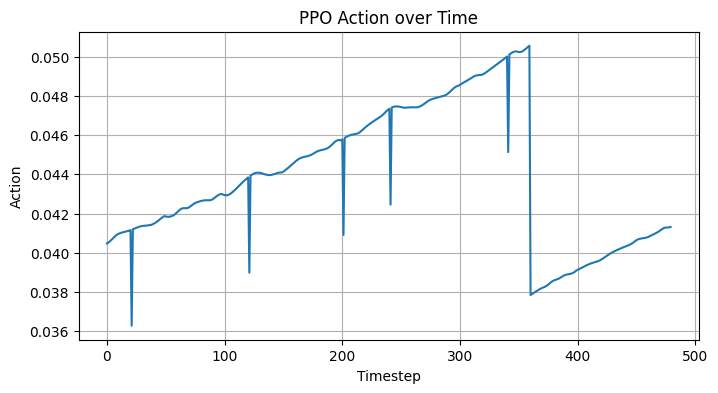

In [107]:
# Convert actions list to a 1D array (handles shape like (1,) or (1,1))
actions_arr = np.array(actions)
actions_arr = np.squeeze(actions_arr)   # makes it 1D if possible

timesteps = np.arange(len(actions_arr))

plt.figure(figsize=(8, 4))
plt.plot(timesteps, actions_arr)
plt.xlabel("Timestep")
plt.ylabel("Action")
plt.title("PPO Action over Time")
plt.grid(True)
plt.show()


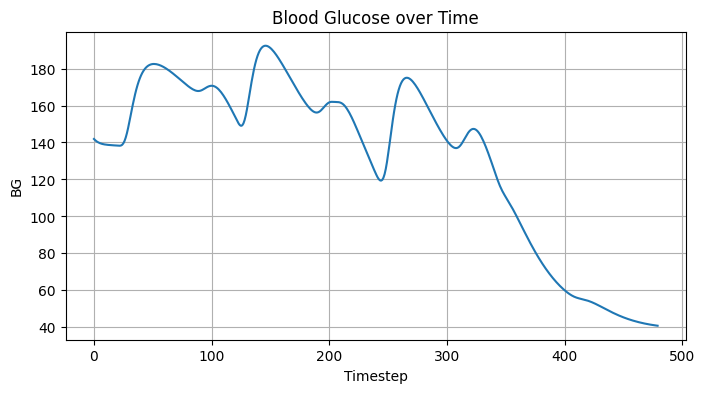

In [108]:
bg_arr_full = np.array(bg_values, dtype=float)

plt.figure(figsize=(8, 4))
plt.plot(timesteps, bg_arr_full[:len(timesteps)])
plt.xlabel("Timestep")
plt.ylabel("BG")
plt.title("Blood Glucose over Time")
plt.grid(True)
plt.show()


In [109]:

# Convert to arrays
actions_arr = np.squeeze(np.array(actions, dtype=float))   # shape -> (T,)
bg_arr = np.array(bg_values, dtype=float)                  # shape -> (T,)

# Filter out steps where BG is missing (None)
valid_mask = ~np.isnan(bg_arr)

actions_valid = actions_arr[valid_mask]
bg_valid = bg_arr[valid_mask]

# Compute Pearson correlation
corr = np.corrcoef(actions_valid, bg_valid)[0, 1]

print("Correlation (actions vs BG):", corr)


Correlation (actions vs BG): 0.46709523966140853


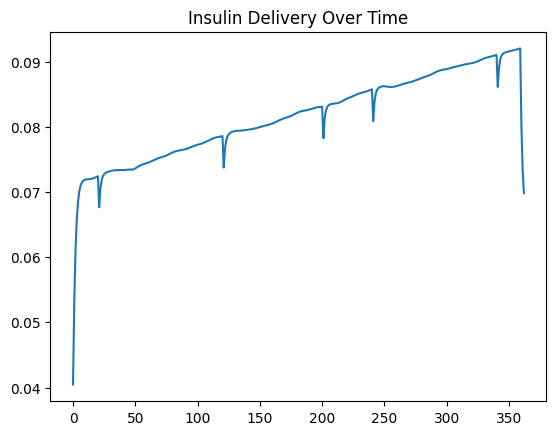

In [110]:
plt.plot(insulin_list)
# plt.ylim(0.08, 0.13)
plt.title("Insulin Delivery Over Time")
plt.show()

In [111]:
import glob
glob.glob("*recurrent*.csv")

['recurrent_ppo_train_monitor_4envs.csv.monitor.csv']

In [112]:
cgm_arr = np.array(cgm_list)
ins_arr = np.array(insulin_list)

print("corr(CGM, insulin):", np.corrcoef(cgm_arr, ins_arr)[0, 1])
print("CGM min/max:", cgm_arr.min(), cgm_arr.max())
print("Ins min/max:", ins_arr.min(), ins_arr.max())


corr(CGM, insulin): -0.8541905298047624
CGM min/max: 0.09749999642372131 0.5242664813995361
Ins min/max: 0.040468089282512665 0.09199757874011993


In [113]:
# from datetime import datetime
# from zoneinfo import ZoneInfo
# import pytz

# la = pytz.timezone("America/Los_Angeles")
# timestamp = datetime.now(la).strftime("%H-%M")   # hour-minute with hyphen
# save_path = f"/content/drive/MyDrive/DiabeteseRL/ppo_Recurrent_{timestamp}"

# recurrent_model.save(save_path)
# print("Saved to:", save_path)